In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("C:/Users/HP/OneDrive/Documents/DataMites/Machine learning/Advertising.csv")


In [4]:
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [5]:
data.tail()

,Unnamed: 0,TV,Radio,Newspaper,Sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [6]:
data.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [8]:
data.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [9]:
data.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

###  Exploratory data analysis

<Axes: xlabel='TV', ylabel='Count'>

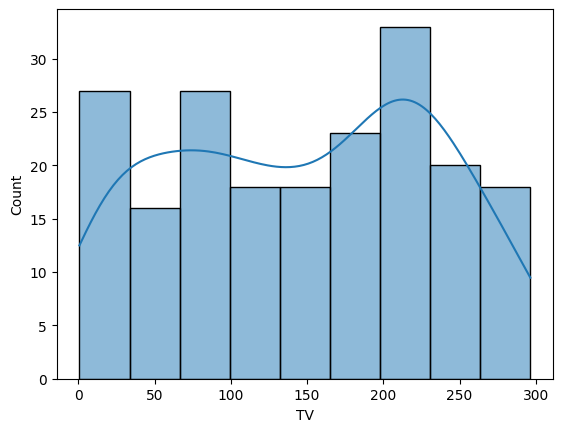

In [10]:
sns.histplot(x=data.TV, kde=True)

<Axes: xlabel='Radio', ylabel='Count'>

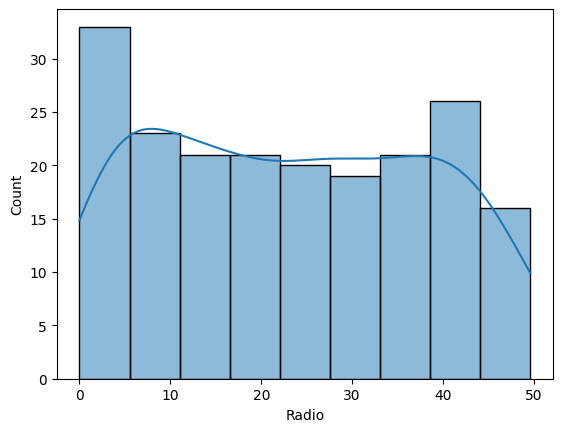

In [11]:
sns.histplot(x=data.Radio, kde=True)

<Axes: xlabel='Newspaper', ylabel='Count'>

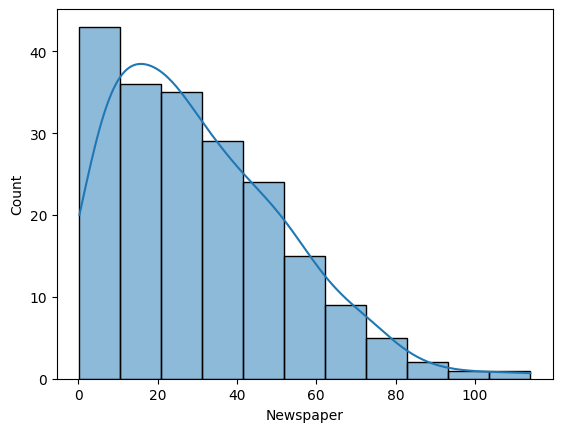

In [12]:
sns.histplot(x=data.Newspaper, kde=True)

<Axes: xlabel='Sales', ylabel='Count'>

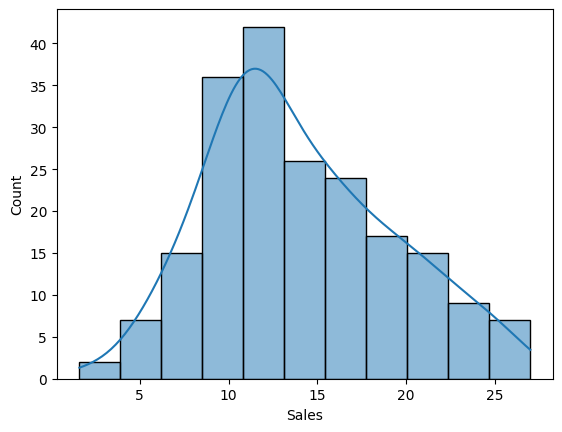

In [13]:
sns.histplot(x=data.Sales, kde=True)

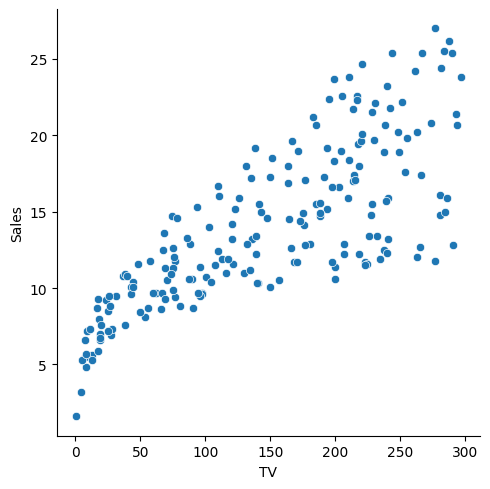

In [14]:
sns.relplot(x='TV', y='Sales', data=data)

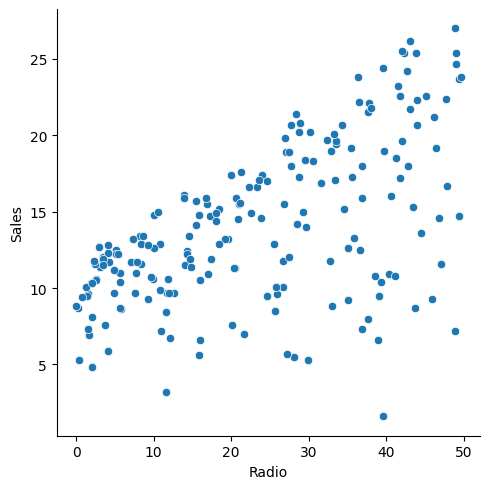

In [15]:
sns.relplot(x='Radio', y='Sales', data=data)

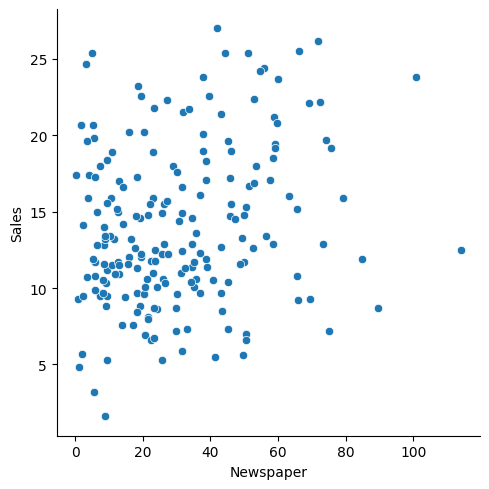

In [16]:
sns.relplot(x='Newspaper', y='Sales', data=data)

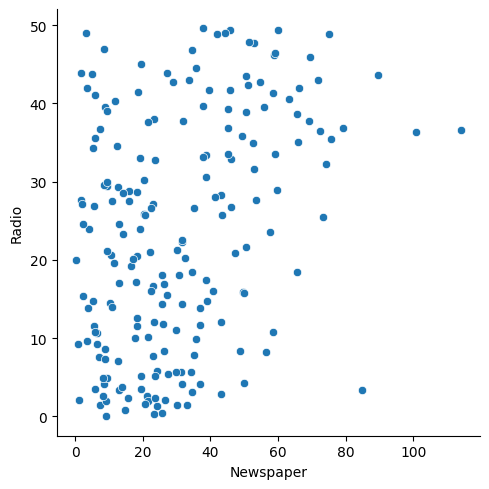

In [17]:
sns.relplot(x='Newspaper', y='Radio', data=data)

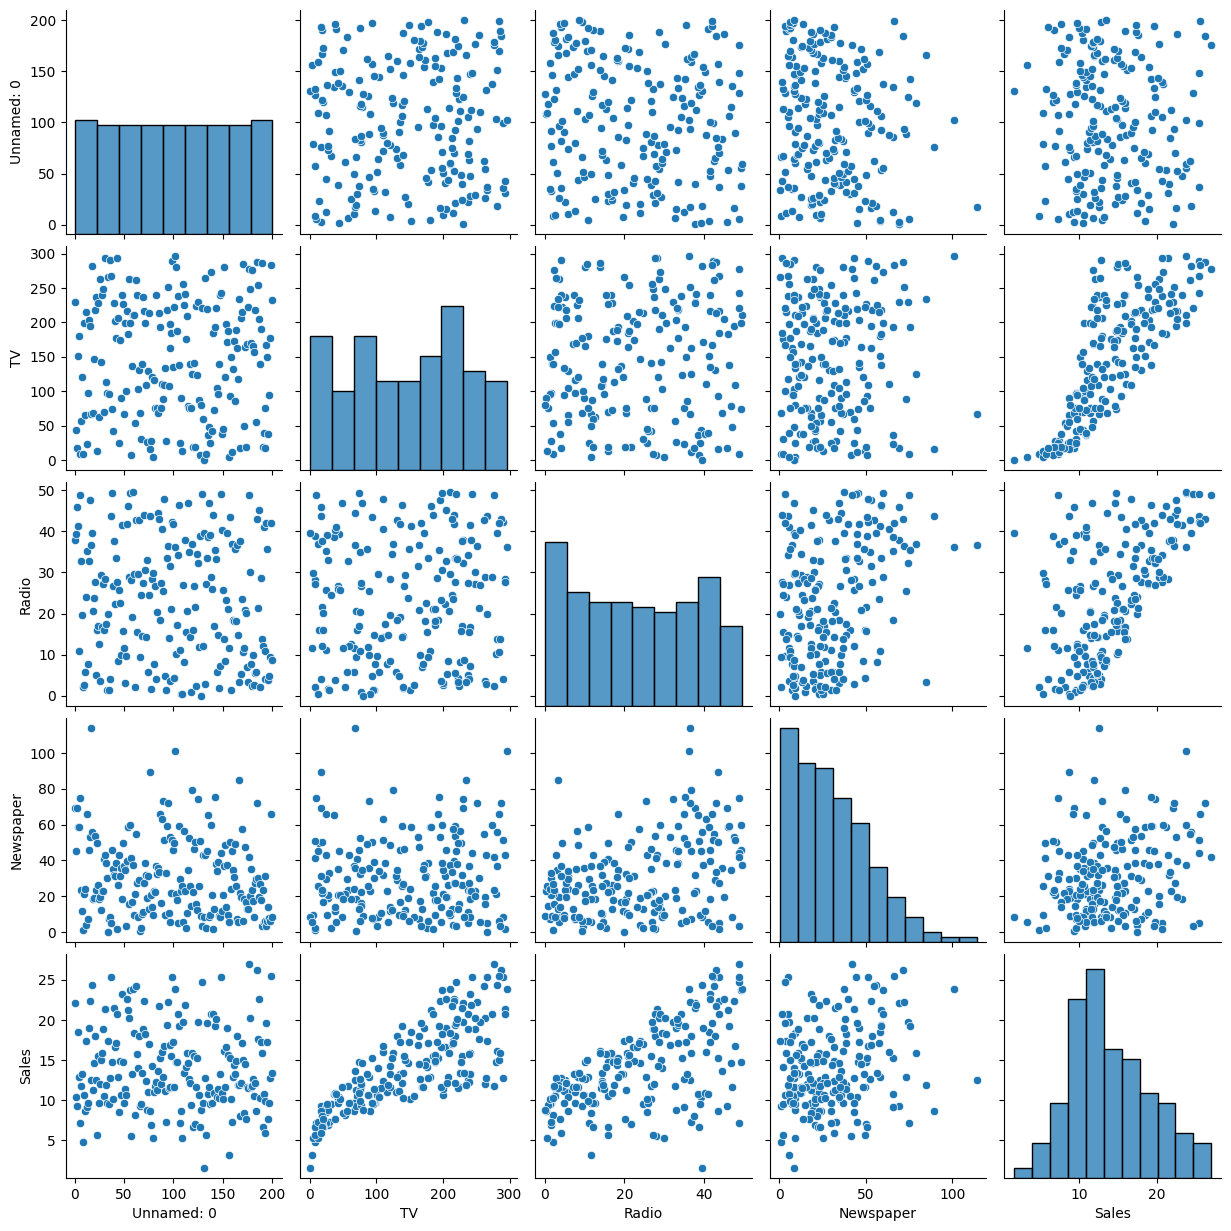

In [18]:
sns.pairplot(data)  # Multivariate

In [19]:
data.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

### Feature Selection

In [20]:
l1 = ["Unnamed: 0"]
data.drop(l1, axis=1 , inplace=True)

In [21]:
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [22]:
data.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


<Axes: >

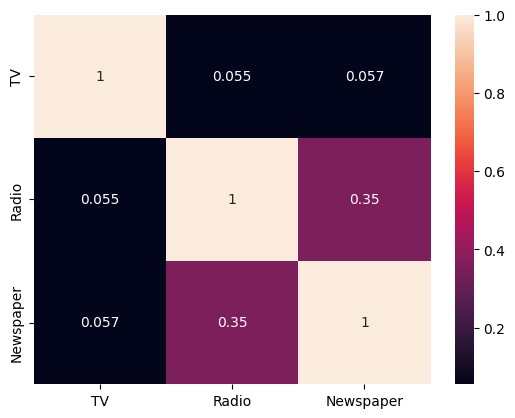

In [23]:
sns.heatmap(data.drop("Sales",axis=1).corr(), annot=True)

#### Model Creation

In [24]:
X = data[["TV","Radio","Newspaper"]]
y= data["Sales"]

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train , y_test = train_test_split(X,y, test_size= 0.2)

In [26]:
from sklearn.linear_model import LinearRegression
LR = LinearRegression()
LR.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
LR .score(X_test, y_test)

0.8348972615070058

In [28]:
y_predict = LR.predict(X_test)
y_predict

array([18.45205275, 17.20827842,  7.85360748,  9.58654846, 14.64597484,
       15.55398777,  8.86386678,  6.05764534, 15.14012398,  3.42429605,
       12.6382638 , 22.22085058,  4.32381234,  3.54606172, 19.69063729,
       12.76294599, 15.28174077,  8.13036097, 14.69964167,  9.5922774 ,
       15.40138881,  9.83458541, 19.47328418, 17.20019403, 10.9564708 ,
        4.35726152, 17.10403906, 16.83210098,  6.93144207, 17.36294247,
       21.73116148, 13.88706413, 14.79220381, 12.57333174, 15.25383748,
       16.3369112 , 13.09128423, 12.12210655, 11.66562462,  9.87395788])

In [29]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
r2Score = r2_score(y_test,y_predict)
mean_squared_error = mean_squared_error(y_test, y_predict)
mean_absolute_error = mean_absolute_error(y_test, y_predict)

In [30]:
print(f" R2 score: {r2Score},\n Mean_squared_error: {mean_squared_error},\n mean_absolute_error: {mean_absolute_error}")

 R2 score: 0.8348972615070058,
 Mean_squared_error: 3.3852005089649566,
 mean_absolute_error: 1.4174126024001275


In [34]:
import statsmodels.api as sm

In [35]:
data.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [36]:
X = data[["TV", "Radio","Newspaper"]]
X = sm.add_constant(X)
X.head()

,const,TV,Radio,Newspaper
0,1.0,230.1,37.8,69.2
1,1.0,44.5,39.3,45.1
2,1.0,17.2,45.9,69.3
3,1.0,151.5,41.3,58.5
4,1.0,180.8,10.8,58.4


In [37]:
y = data["Sales"]

In [38]:
model = sm.OLS(y,X).fit()
print("R- Squared", model.rsquared)
print("Adjusted R- Squared:", model.rsquared_adj)

R- Squared 0.8972106381789521
Adjusted R- Squared: 0.8956373316204667
